In [10]:
import numpy as np
import pickle
import torch
import os, sys
helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [11]:
# Import MC samples
scaler_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers"
mc_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/data"
# signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal"
signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/lxplus_signal"
# signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/final_signals"
# signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal_MII"

var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]

# Load MC samples

mc_events = np.load(f"{mc_path}/mc_events_chunk03.npz", allow_pickle=True)

with open(f"{scaler_path}/mc_scaler_chunk03.pkl","rb") as f:
    mc_scaler = pickle.load(f)

print(mc_events["mc_events_sr"].shape)


signal_samples = {}
signal_modes = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]
# signal_modes = ["1000_2"]

# Import signal samples
all_columns = [
    "pT_j1", "eta_j1", "phi_j1",
    "pT_j2", "eta_j2", "phi_j2",
    "m_jj", "tau21_j1", "tau21_j2",
    "tau32_j1", "tau32_j2",
    "met", "phi_met", "min_dPhi", "ht"
]

# Find indices of desired variables
cols_to_use = [all_columns.index(v) for v in var_names]

def sr_mask(events):
    ht = events[:,0]
    met = events[:,1]
    # Apply SR cuts
    mask = (ht > 600) & (met > 600)
    return mask

for mode in signal_modes:
    signal_data = np.loadtxt(f"{signal_path}/{mode}_events.txt", skiprows=1, usecols=cols_to_use)
    # print(signal_data[0])
    sig_mask = sr_mask(signal_data)
    signal_samples[mode] = mc_scaler.transform(signal_data[sig_mask])
    print(f"Loaded signal mode {mode} with shape: {signal_data.shape}")
    print(f"After SR cuts, shape: {signal_samples[mode].shape}")

(46968, 7)
Loaded signal mode 1000_2 with shape: (9976, 7)
After SR cuts, shape: (177, 7)
Loaded signal mode 1000_4 with shape: (9601, 7)
After SR cuts, shape: (379, 7)
Loaded signal mode 1000_6 with shape: (6130, 7)
After SR cuts, shape: (394, 7)
Loaded signal mode 1000_8 with shape: (3539, 7)
After SR cuts, shape: (352, 7)
Loaded signal mode 2000_2 with shape: (38262, 7)
After SR cuts, shape: (5783, 7)
Loaded signal mode 2000_4 with shape: (29563, 7)
After SR cuts, shape: (8288, 7)
Loaded signal mode 2000_6 with shape: (20689, 7)
After SR cuts, shape: (8300, 7)
Loaded signal mode 2000_8 with shape: (11715, 7)
After SR cuts, shape: (6061, 7)
Loaded signal mode 3000_2 with shape: (17591, 7)
After SR cuts, shape: (4755, 7)
Loaded signal mode 3000_4 with shape: (14230, 7)
After SR cuts, shape: (6471, 7)
Loaded signal mode 3000_6 with shape: (10260, 7)
After SR cuts, shape: (6147, 7)
Loaded signal mode 3000_8 with shape: (5946, 7)
After SR cuts, shape: (4274, 7)


In [12]:
mixed_data = {}
for mode in signal_modes:
    mixed_data[mode] = np.vstack((mc_events["mc_events_sr"], signal_samples[mode]))
    print(f"Mixed data for mode {mode} has shape: {mixed_data[mode].shape}")

Mixed data for mode 1000_2 has shape: (47145, 7)
Mixed data for mode 1000_4 has shape: (47347, 7)
Mixed data for mode 1000_6 has shape: (47362, 7)
Mixed data for mode 1000_8 has shape: (47320, 7)
Mixed data for mode 2000_2 has shape: (52751, 7)
Mixed data for mode 2000_4 has shape: (55256, 7)
Mixed data for mode 2000_6 has shape: (55268, 7)
Mixed data for mode 2000_8 has shape: (53029, 7)
Mixed data for mode 3000_2 has shape: (51723, 7)
Mixed data for mode 3000_4 has shape: (53439, 7)
Mixed data for mode 3000_6 has shape: (53115, 7)
Mixed data for mode 3000_8 has shape: (51242, 7)


In [13]:
x_test = {}
y_test = {}

n_bkg = mc_events["mc_events_sr"].shape[0]

for mode in signal_modes:
    n_sig = signal_samples[mode].shape[0]

    # x_test = mixed features (already scaled)
    x_test[mode] = mixed_data[mode]

    # y_test = 0 for background, 1 for signal
    y_bkg = np.zeros(n_bkg)
    y_sig = np.ones(n_sig)
    y_test[mode] = np.concatenate((y_bkg, y_sig))

    print(f"Mode {mode}: x_test {x_test[mode].shape}, y_test {y_test[mode].shape}")


Mode 1000_2: x_test (47145, 7), y_test (47145,)
Mode 1000_4: x_test (47347, 7), y_test (47347,)
Mode 1000_6: x_test (47362, 7), y_test (47362,)
Mode 1000_8: x_test (47320, 7), y_test (47320,)
Mode 2000_2: x_test (52751, 7), y_test (52751,)
Mode 2000_4: x_test (55256, 7), y_test (55256,)
Mode 2000_6: x_test (55268, 7), y_test (55268,)
Mode 2000_8: x_test (53029, 7), y_test (53029,)
Mode 3000_2: x_test (51723, 7), y_test (51723,)
Mode 3000_4: x_test (53439, 7), y_test (53439,)
Mode 3000_6: x_test (53115, 7), y_test (53115,)
Mode 3000_8: x_test (51242, 7), y_test (51242,)


In [14]:
# Load Trained Machine Learning models

import glob

base_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr"

# Datasets
datasets = [f"Data0{i}" for i in range(1, 6)]

# Initialize dicts
generate_models_paths = {}
reweight_models_paths = {}

for d in datasets:
    # Collect .pt files belonging to this dataset
    gen_models = sorted(glob.glob(f"{base_path}/model_generate_SR_{d}_MC*run*.pt"))
    rew_models = sorted(glob.glob(f"{base_path}/model_reweight_SR_{d}_MC*run*.pt"))

    generate_models_paths[d] = gen_models
    reweight_models_paths[d] = rew_models

    print(f"{d}: {len(gen_models)} generate models, {len(rew_models)} reweight models")

# Optional sanity check
# print("\nExample:")
# print("Data01 generate models:", generate_models_paths["Data01"][:3])
# print("Data01 reweight models:", reweight_models_paths["Data01"][:3])

Data01: 20 generate models, 20 reweight models
Data02: 20 generate models, 20 reweight models
Data03: 20 generate models, 20 reweight models
Data04: 20 generate models, 20 reweight models
Data05: 20 generate models, 20 reweight models


In [15]:
print("mc_events_sr shape:", mc_events["mc_events_sr"].shape)
for mode in signal_modes:
    print(mode, "signal shape:", signal_samples[mode].shape, "mixed:", mixed_data[mode].shape)
    print(" label counts:", np.unique(y_test[mode], return_counts=True))
    print(" first 5 y:", y_test[mode][:10])
    # print(" example features (first row):", x_test[mode][0])

mc_events_sr shape: (46968, 7)
1000_2 signal shape: (177, 7) mixed: (47145, 7)
 label counts: (array([0., 1.]), array([46968,   177]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_4 signal shape: (379, 7) mixed: (47347, 7)
 label counts: (array([0., 1.]), array([46968,   379]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_6 signal shape: (394, 7) mixed: (47362, 7)
 label counts: (array([0., 1.]), array([46968,   394]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_8 signal shape: (352, 7) mixed: (47320, 7)
 label counts: (array([0., 1.]), array([46968,   352]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_2 signal shape: (5783, 7) mixed: (52751, 7)
 label counts: (array([0., 1.]), array([46968,  5783]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_4 signal shape: (8288, 7) mixed: (55256, 7)
 label counts: (array([0., 1.]), array([46968,  8288]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_6 signal shape: (8300, 7) mixed: (55268, 7)
 label counts: (array([0., 1.]


=== Evaluating models for Data01 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt


      AUC = 0.6625, MaxSIC = 1.0880
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6625, MaxSIC = 1.0804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6718, MaxSIC = 1.0935
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6645, MaxSIC = 1.0920
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6692, MaxSIC = 1.0893
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6541, MaxSIC = 1.0878
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6618, MaxSIC = 1.0859
   ▶️ Run 08: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run15.pt
      AUC = 0.6643, M

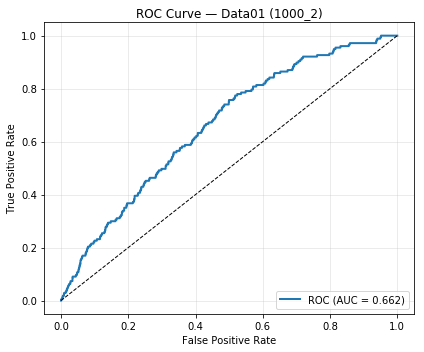

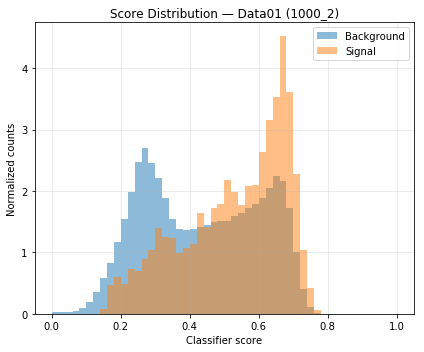


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6834, MaxSIC = 1.1244
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6859, MaxSIC = 1.1341
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6913, MaxSIC = 1.1418
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6861, MaxSIC = 1.1345
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6906, MaxSIC = 1.1381
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6796, MaxSIC = 1.1399
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6793, MaxSIC = 

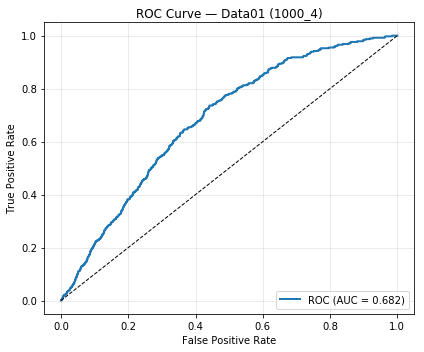

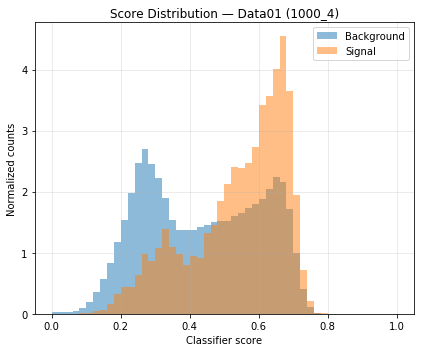


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6873, MaxSIC = 1.1294
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6880, MaxSIC = 1.1372
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6960, MaxSIC = 1.1579
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6893, MaxSIC = 1.1224
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6925, MaxSIC = 1.1401
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6844, MaxSIC = 1.1308
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6834, MaxSIC = 

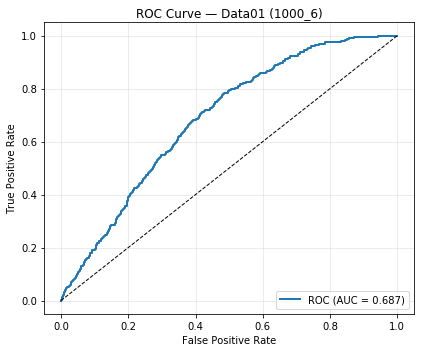

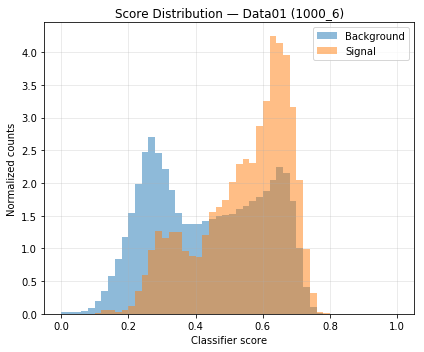


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6670, MaxSIC = 1.1351
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6651, MaxSIC = 1.1308
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6748, MaxSIC = 1.1355
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6669, MaxSIC = 1.1333
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6704, MaxSIC = 1.1320
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6593, MaxSIC = 1.1346
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6589, MaxSIC = 

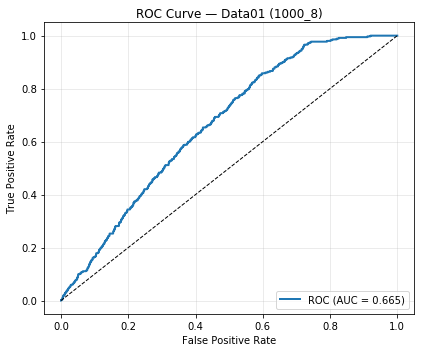

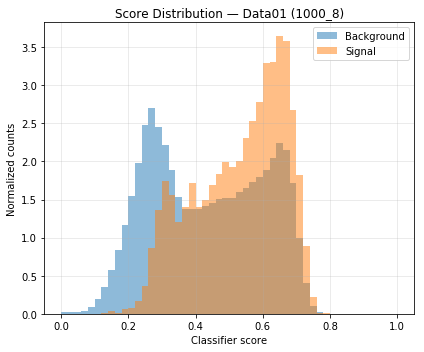


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5783, MaxSIC = 1.0335
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5773, MaxSIC = 1.0340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5820, MaxSIC = 1.0314
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5802, MaxSIC = 1.0313
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5798, MaxSIC = 1.0368
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5750, MaxSIC = 1.0311
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5764, MaxSIC = 

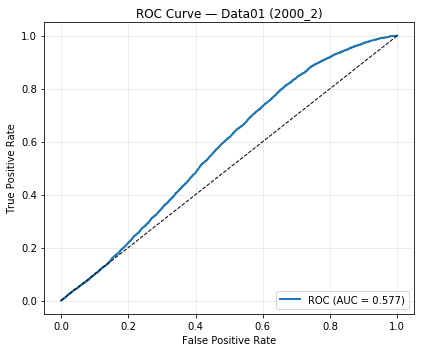

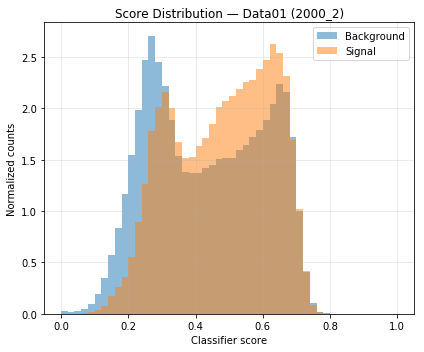


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5869, MaxSIC = 1.0397
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5867, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5913, MaxSIC = 1.0398
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5894, MaxSIC = 1.0387
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5888, MaxSIC = 1.0430
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5842, MaxSIC = 1.0388
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5854, MaxSIC = 

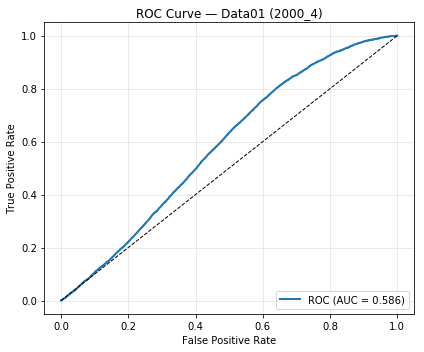

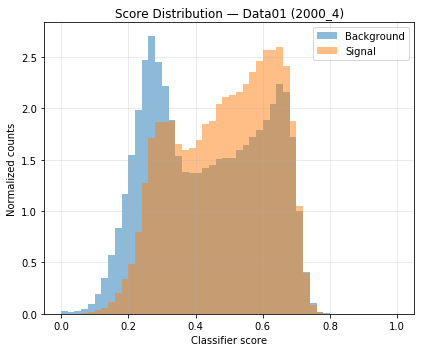


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5855, MaxSIC = 1.0394
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5846, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5904, MaxSIC = 1.0386
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5880, MaxSIC = 1.0363
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5879, MaxSIC = 1.0391
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5826, MaxSIC = 1.0352
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5833, MaxSIC = 

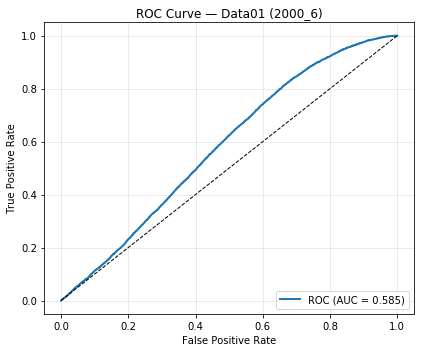

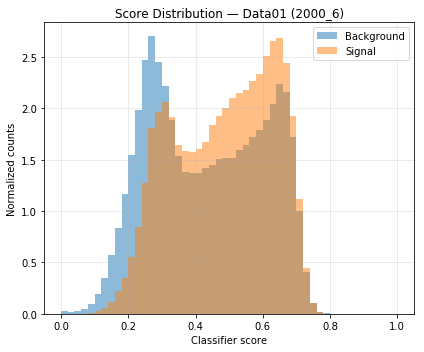


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5781, MaxSIC = 1.0346
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5770, MaxSIC = 1.0346
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5817, MaxSIC = 1.0333
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5795, MaxSIC = 1.0304
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5789, MaxSIC = 1.0338
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5738, MaxSIC = 1.0316
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5749, MaxSIC = 

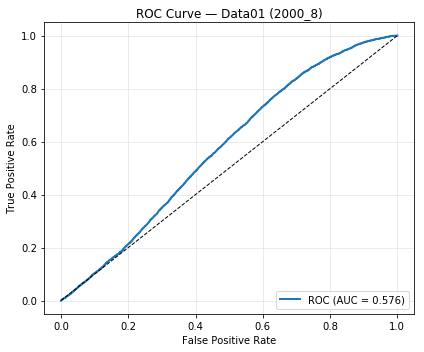

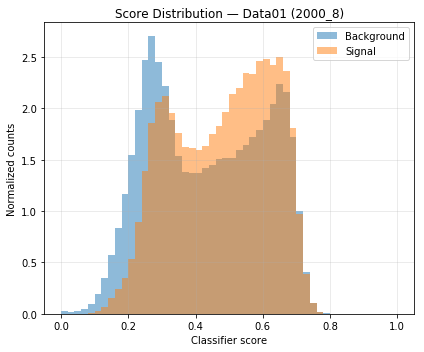


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4204, MaxSIC = 1.0016
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4186, MaxSIC = 1.0026
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4229, MaxSIC = 1.0031
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4244, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.4220, MaxSIC = 1.0012
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4191, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4222, MaxSIC = 

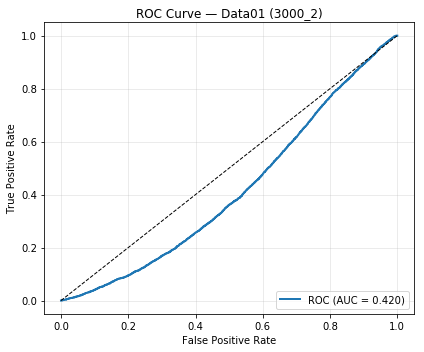

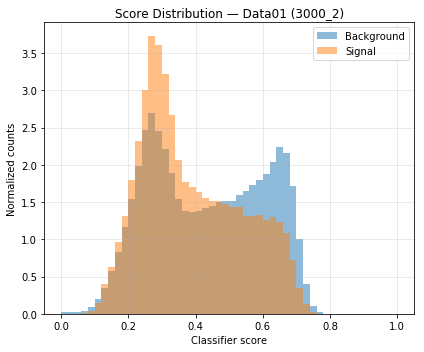


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4418, MaxSIC = 1.0009
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4416, MaxSIC = 1.0015
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4450, MaxSIC = 1.0021
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4463, MaxSIC = 1.0013
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.4449, MaxSIC = 1.0010
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4405, MaxSIC = 1.0008
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4439, MaxSIC = 

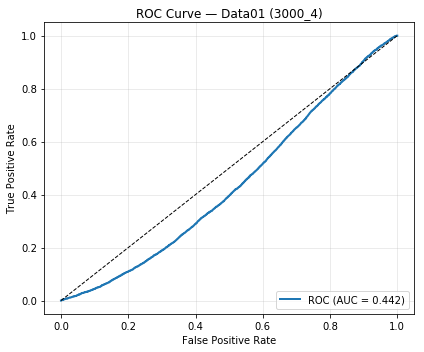

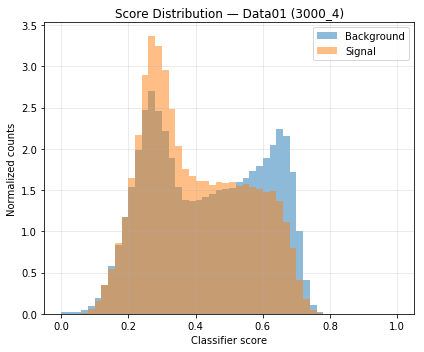


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4608, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4597, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4641, MaxSIC = 1.0027
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4654, MaxSIC = 1.0012
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.4631, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4592, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4623, MaxSIC = 

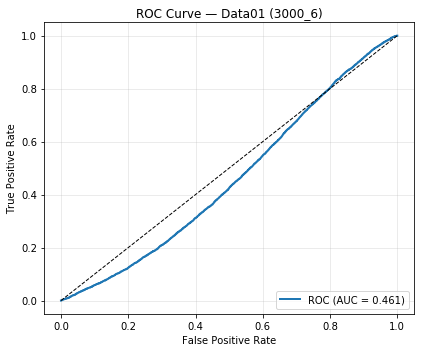

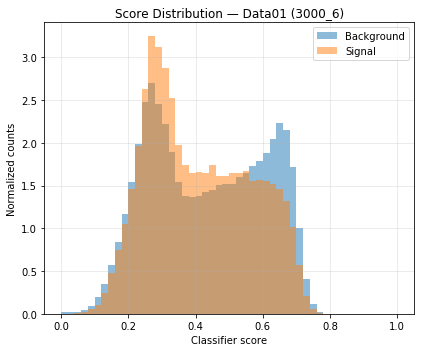


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4670, MaxSIC = 1.0015
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4656, MaxSIC = 1.0018
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4694, MaxSIC = 1.0026
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4702, MaxSIC = 1.0015
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.4687, MaxSIC = 1.0015
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4645, MaxSIC = 1.0007
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4677, MaxSIC = 

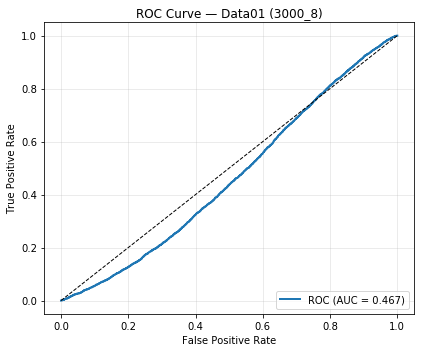

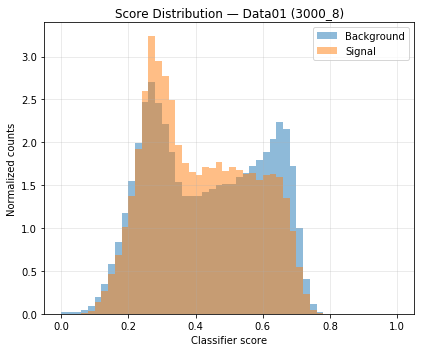


=== Evaluating models for Data02 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6603, MaxSIC = 1.0881
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6625, MaxSIC = 1.0804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6718, MaxSIC = 1.0935
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6645, MaxSIC = 1.0920
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6692, MaxSIC = 1.0893
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6541, MaxSIC = 1.0878
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_

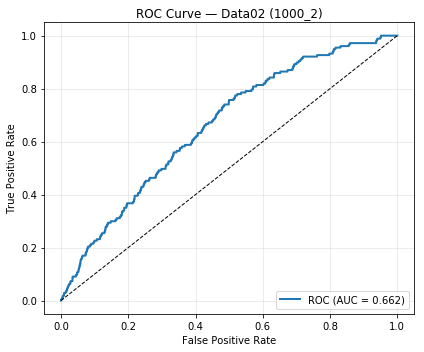

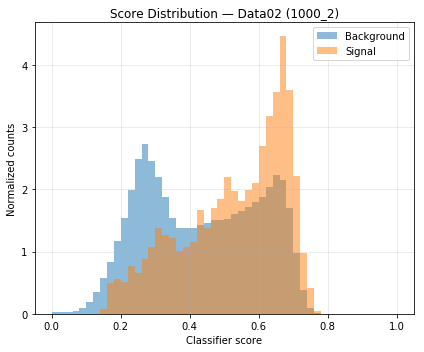


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6840, MaxSIC = 1.1234
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6859, MaxSIC = 1.1341
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6913, MaxSIC = 1.1418
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6861, MaxSIC = 1.1345
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6906, MaxSIC = 1.1381
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6796, MaxSIC = 1.1399
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6793, MaxSIC = 

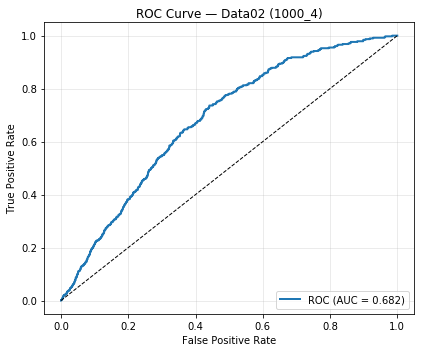

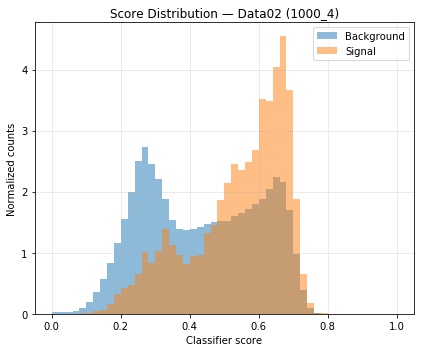


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6872, MaxSIC = 1.1290
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6880, MaxSIC = 1.1372
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6960, MaxSIC = 1.1579
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6893, MaxSIC = 1.1224
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6925, MaxSIC = 1.1401
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6844, MaxSIC = 1.1308
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6834, MaxSIC = 

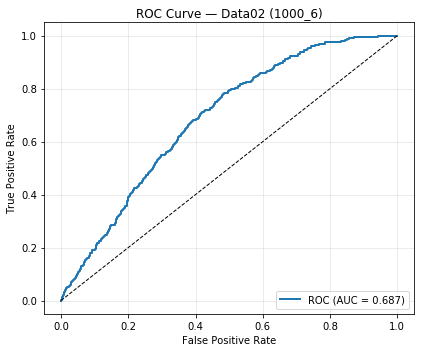

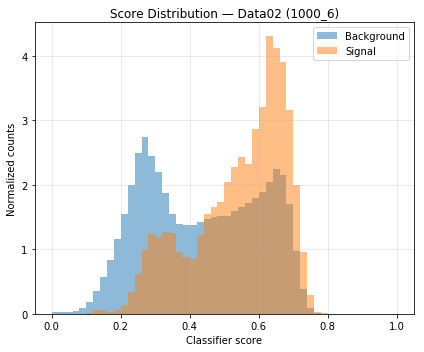


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6690, MaxSIC = 1.1348
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6651, MaxSIC = 1.1308
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6748, MaxSIC = 1.1355
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6669, MaxSIC = 1.1333
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6704, MaxSIC = 1.1320
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6593, MaxSIC = 1.1346
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6589, MaxSIC = 

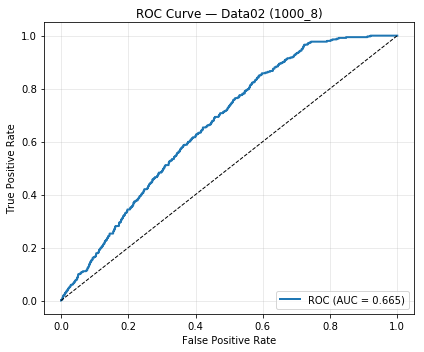

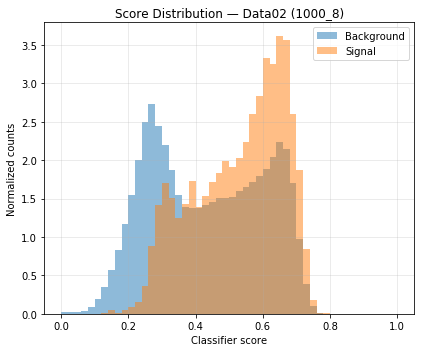


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5784, MaxSIC = 1.0327
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5773, MaxSIC = 1.0340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5820, MaxSIC = 1.0314
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5802, MaxSIC = 1.0313
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5798, MaxSIC = 1.0368
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5750, MaxSIC = 1.0311
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5764, MaxSIC = 

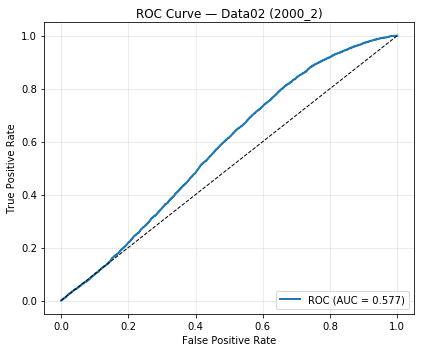

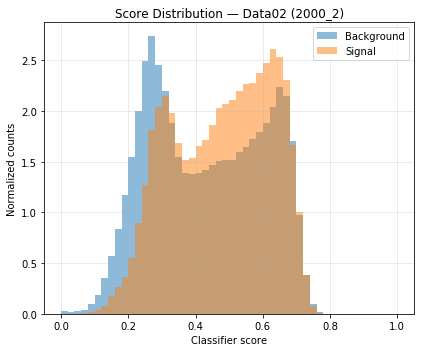


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5870, MaxSIC = 1.0391
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5867, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5913, MaxSIC = 1.0398
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5894, MaxSIC = 1.0387
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5888, MaxSIC = 1.0430
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5842, MaxSIC = 1.0388
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5854, MaxSIC = 

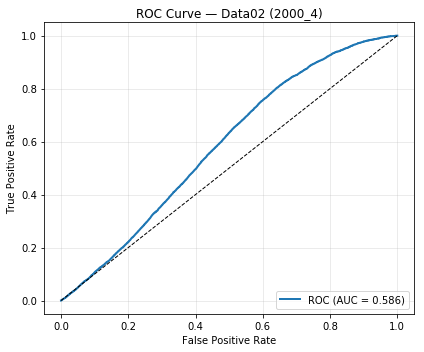

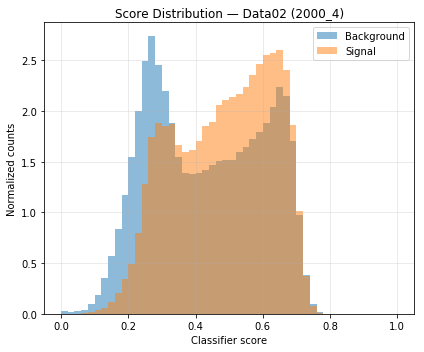


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5858, MaxSIC = 1.0333
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5846, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5904, MaxSIC = 1.0386
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5880, MaxSIC = 1.0363
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5879, MaxSIC = 1.0391
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5826, MaxSIC = 1.0352
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5833, MaxSIC = 

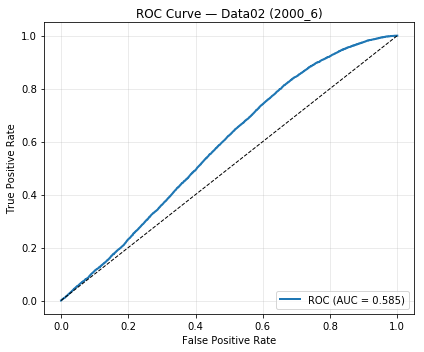

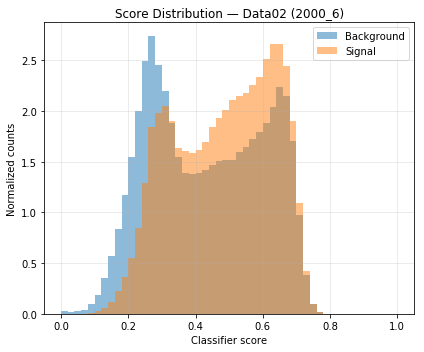


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5774, MaxSIC = 1.0297
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5770, MaxSIC = 1.0346
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5817, MaxSIC = 1.0333
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5795, MaxSIC = 1.0304
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5789, MaxSIC = 1.0338
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5738, MaxSIC = 1.0316
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5749, MaxSIC = 

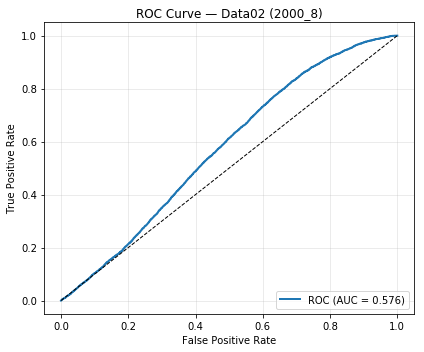

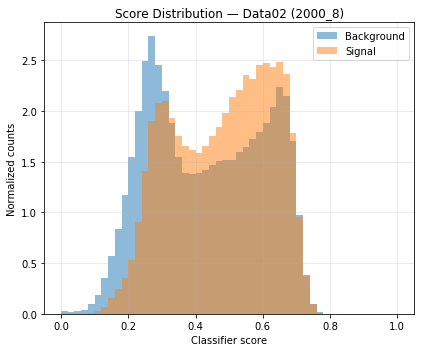


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4227, MaxSIC = 1.0017
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4186, MaxSIC = 1.0026
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4229, MaxSIC = 1.0031
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4244, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4220, MaxSIC = 1.0012
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4191, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.4222, MaxSIC = 

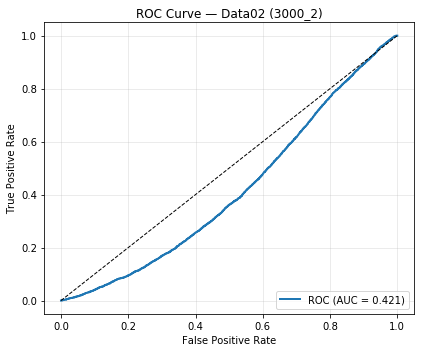

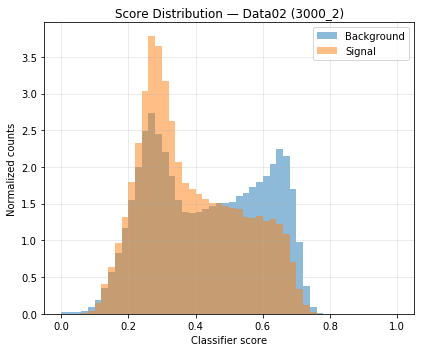


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4445, MaxSIC = 1.0012
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4416, MaxSIC = 1.0015
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4450, MaxSIC = 1.0021
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4463, MaxSIC = 1.0013
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4449, MaxSIC = 1.0010
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4405, MaxSIC = 1.0008
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.4439, MaxSIC = 

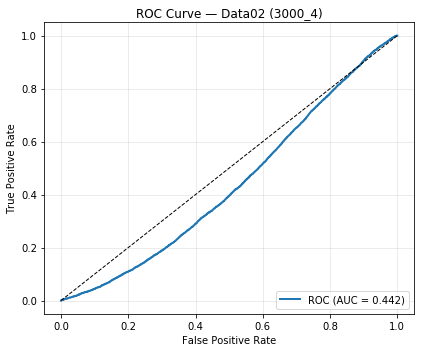

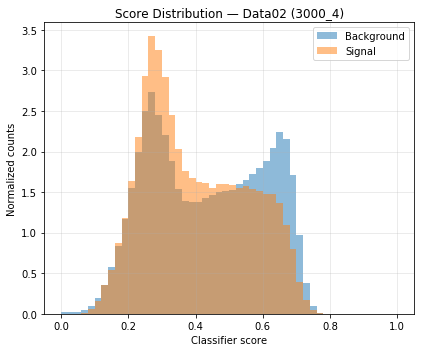


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4625, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4597, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4641, MaxSIC = 1.0027
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4654, MaxSIC = 1.0012
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4631, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4592, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.4623, MaxSIC = 

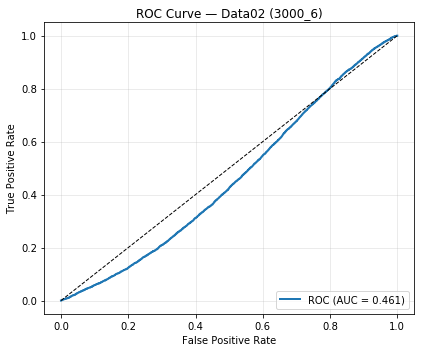

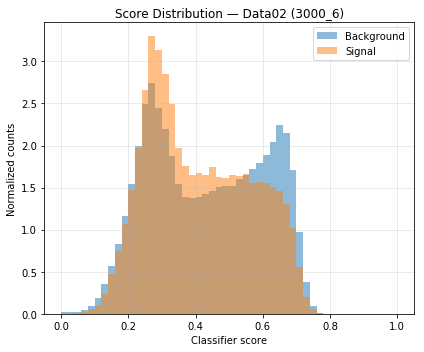


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4697, MaxSIC = 1.0016
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4656, MaxSIC = 1.0018
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4694, MaxSIC = 1.0026
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4702, MaxSIC = 1.0015
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4687, MaxSIC = 1.0015
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4645, MaxSIC = 1.0007
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.4677, MaxSIC = 

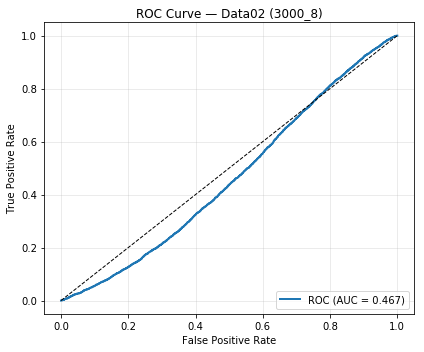

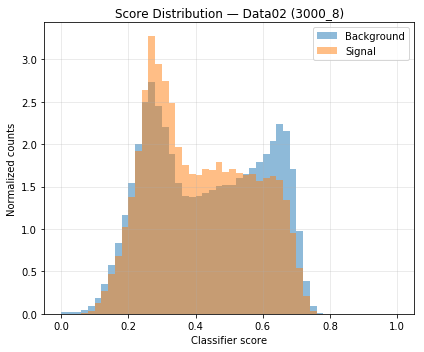


=== Evaluating models for Data03 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6603, MaxSIC = 1.0881
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6625, MaxSIC = 1.0804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6718, MaxSIC = 1.0935
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6645, MaxSIC = 1.0920
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6692, MaxSIC = 1.0893
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6541, MaxSIC = 1.0878
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_

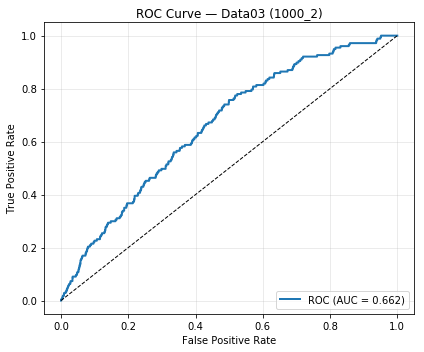

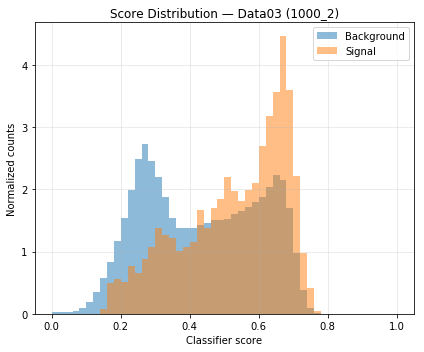


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6840, MaxSIC = 1.1234
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6859, MaxSIC = 1.1341
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6913, MaxSIC = 1.1418
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6861, MaxSIC = 1.1345
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6906, MaxSIC = 1.1381
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6796, MaxSIC = 1.1399
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6793, MaxSIC = 

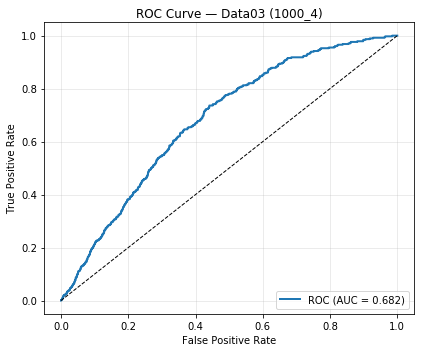

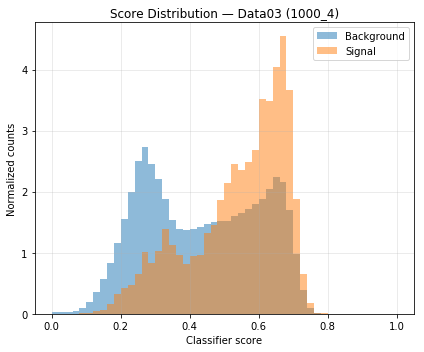


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6872, MaxSIC = 1.1290
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6880, MaxSIC = 1.1372
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6960, MaxSIC = 1.1579
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6893, MaxSIC = 1.1224
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6925, MaxSIC = 1.1401
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6844, MaxSIC = 1.1308
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6834, MaxSIC = 

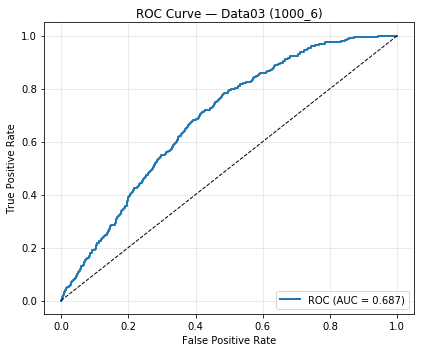

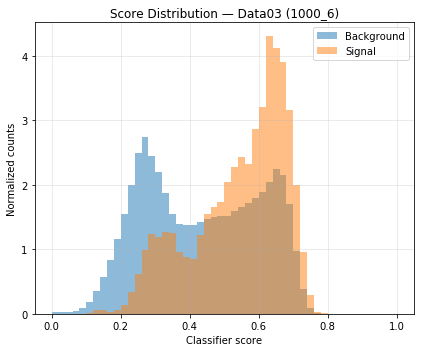


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6690, MaxSIC = 1.1348
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6651, MaxSIC = 1.1308
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6748, MaxSIC = 1.1355
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6669, MaxSIC = 1.1333
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6704, MaxSIC = 1.1320
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6593, MaxSIC = 1.1346
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6589, MaxSIC = 

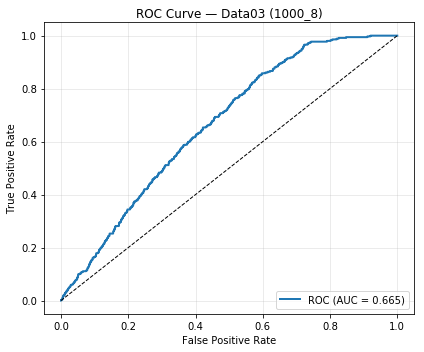

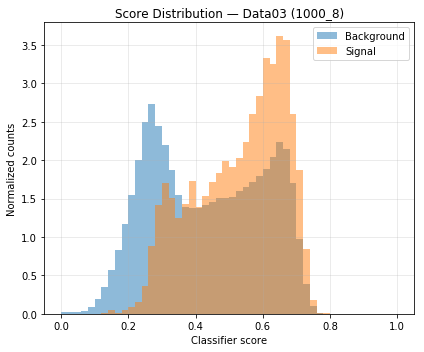


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5784, MaxSIC = 1.0327
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5773, MaxSIC = 1.0340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5820, MaxSIC = 1.0314
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5802, MaxSIC = 1.0313
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5798, MaxSIC = 1.0368
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5750, MaxSIC = 1.0311
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5764, MaxSIC = 

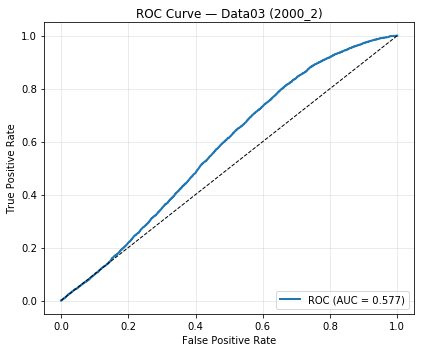

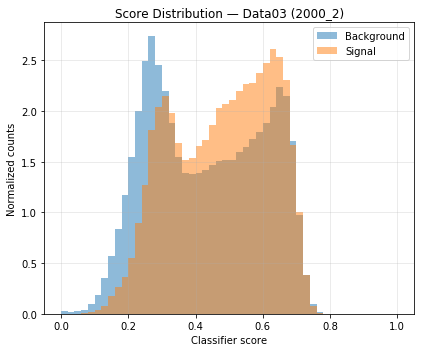


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5870, MaxSIC = 1.0391
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5867, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5913, MaxSIC = 1.0398
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5894, MaxSIC = 1.0387
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5888, MaxSIC = 1.0430
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5842, MaxSIC = 1.0388
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5854, MaxSIC = 

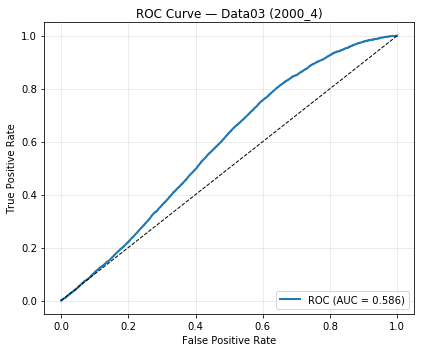

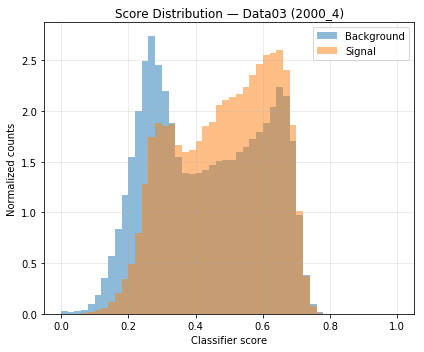


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5858, MaxSIC = 1.0333
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5846, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5904, MaxSIC = 1.0386
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5880, MaxSIC = 1.0363
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5879, MaxSIC = 1.0391
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5826, MaxSIC = 1.0352
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5833, MaxSIC = 

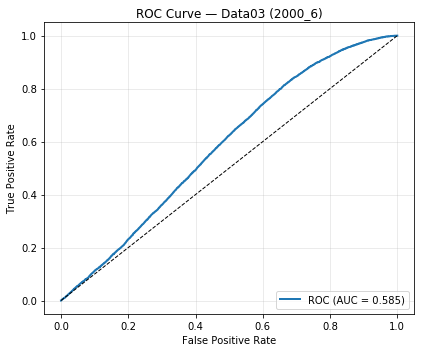

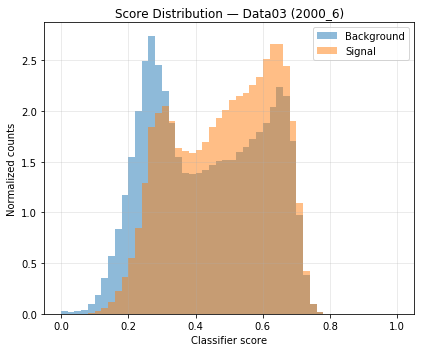


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5774, MaxSIC = 1.0297
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5770, MaxSIC = 1.0346
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5817, MaxSIC = 1.0333
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5795, MaxSIC = 1.0304
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5789, MaxSIC = 1.0338
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5738, MaxSIC = 1.0316
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5749, MaxSIC = 

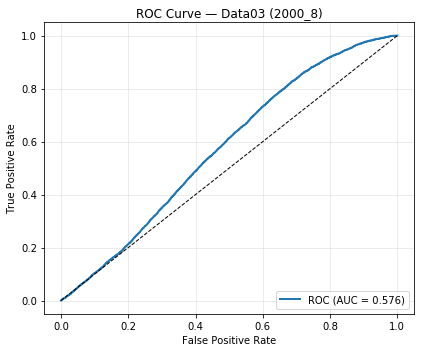

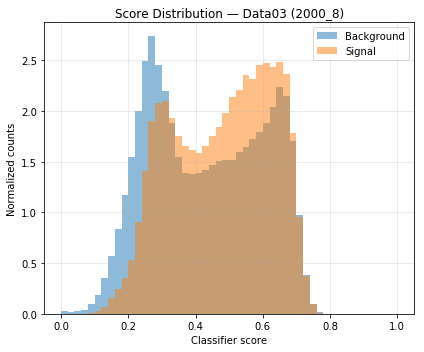


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4227, MaxSIC = 1.0017
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4186, MaxSIC = 1.0026
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4229, MaxSIC = 1.0031
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4244, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4220, MaxSIC = 1.0012
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4191, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.4222, MaxSIC = 

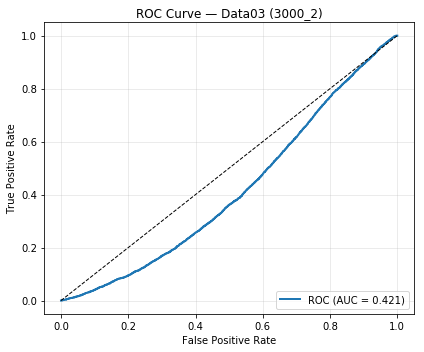

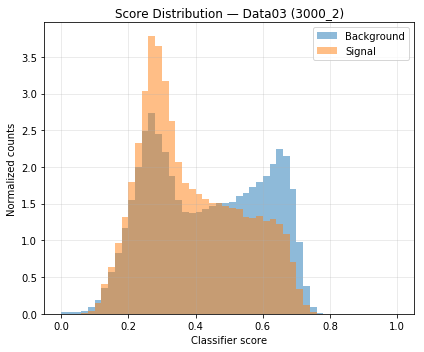


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4445, MaxSIC = 1.0012
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4416, MaxSIC = 1.0015
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4450, MaxSIC = 1.0021
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4463, MaxSIC = 1.0013
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4449, MaxSIC = 1.0010
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4405, MaxSIC = 1.0008
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.4439, MaxSIC = 

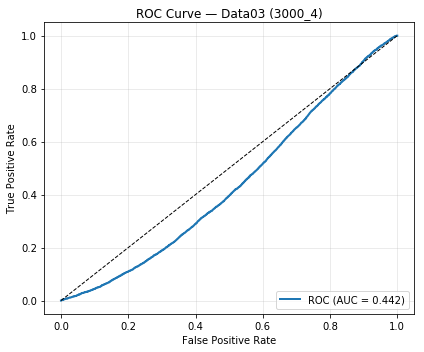

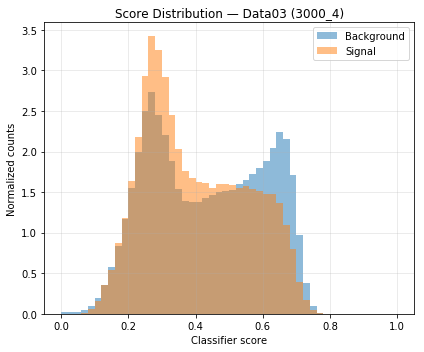


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4625, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4597, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4641, MaxSIC = 1.0027
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4654, MaxSIC = 1.0012
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4631, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4592, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.4623, MaxSIC = 

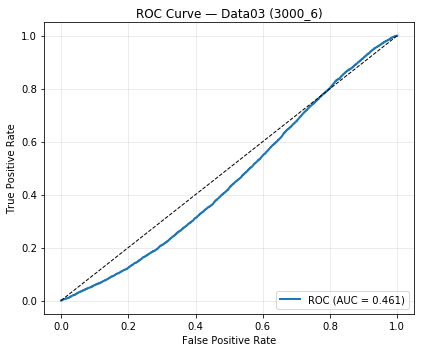

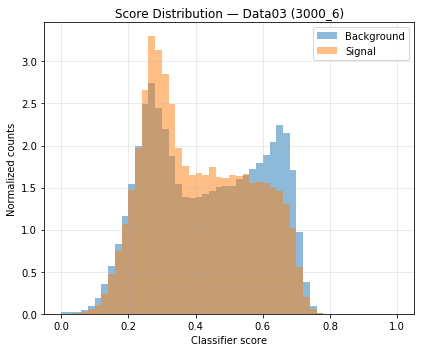


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4697, MaxSIC = 1.0016
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4656, MaxSIC = 1.0018
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4694, MaxSIC = 1.0026
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4702, MaxSIC = 1.0015
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4687, MaxSIC = 1.0015
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4645, MaxSIC = 1.0007
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.4677, MaxSIC = 

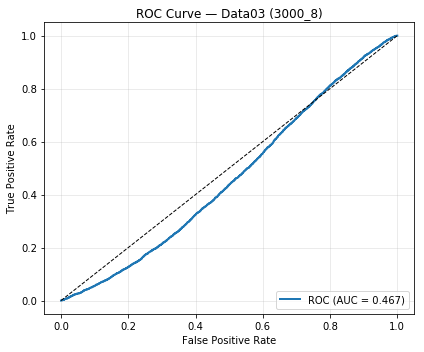

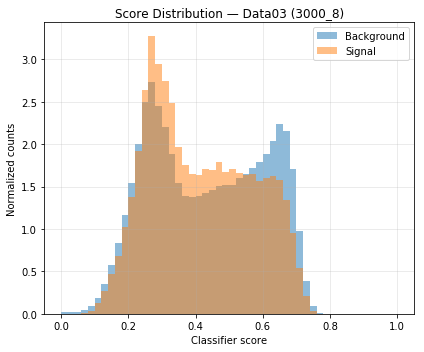


=== Evaluating models for Data04 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6603, MaxSIC = 1.0881
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6625, MaxSIC = 1.0804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6718, MaxSIC = 1.0935
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6645, MaxSIC = 1.0920
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6692, MaxSIC = 1.0893
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6541, MaxSIC = 1.0878
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_

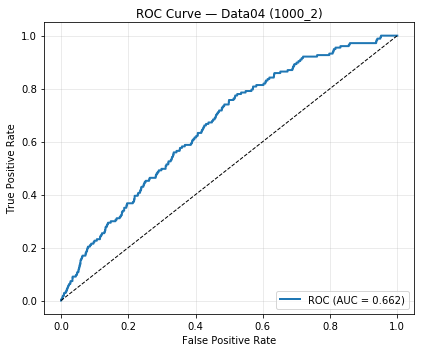

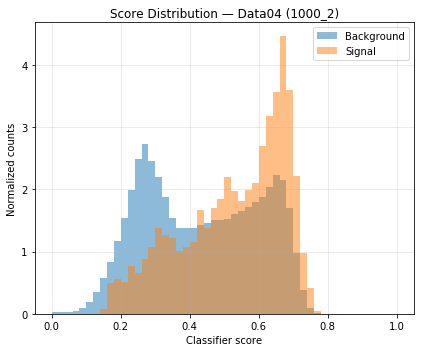


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6840, MaxSIC = 1.1234
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6859, MaxSIC = 1.1341
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6913, MaxSIC = 1.1418
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6861, MaxSIC = 1.1345
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6906, MaxSIC = 1.1381
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6796, MaxSIC = 1.1399
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6793, MaxSIC = 

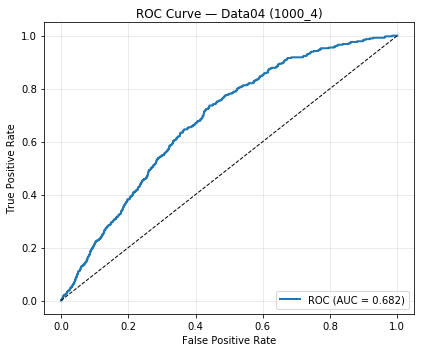

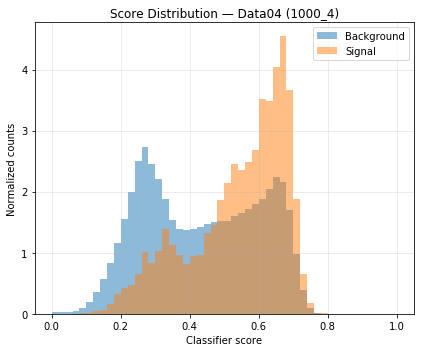


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6872, MaxSIC = 1.1290
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6880, MaxSIC = 1.1372
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6960, MaxSIC = 1.1579
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6893, MaxSIC = 1.1224
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6925, MaxSIC = 1.1401
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6844, MaxSIC = 1.1308
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6834, MaxSIC = 

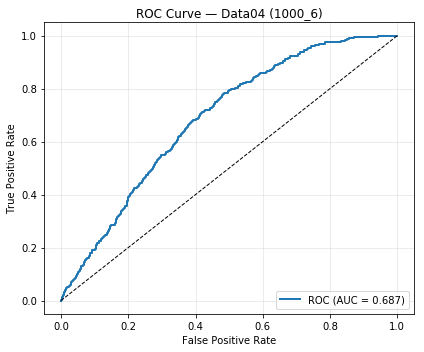

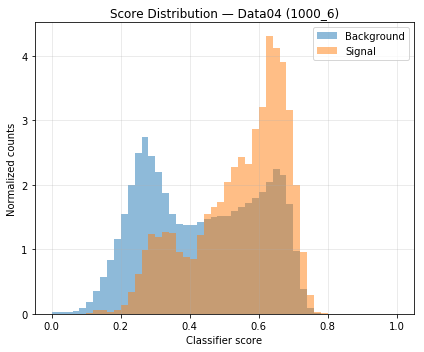


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6690, MaxSIC = 1.1348
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6651, MaxSIC = 1.1308
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6748, MaxSIC = 1.1355
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6669, MaxSIC = 1.1333
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6704, MaxSIC = 1.1320
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6593, MaxSIC = 1.1346
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6589, MaxSIC = 

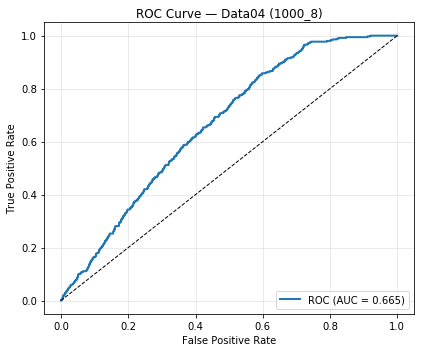

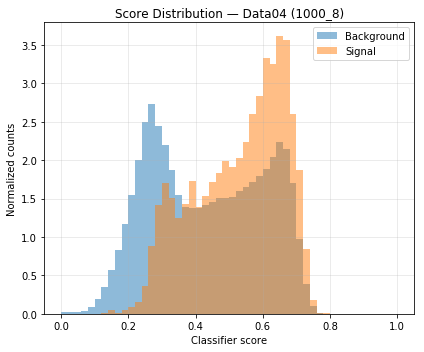


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5784, MaxSIC = 1.0327
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5773, MaxSIC = 1.0340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5820, MaxSIC = 1.0314
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5802, MaxSIC = 1.0313
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5798, MaxSIC = 1.0368
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5750, MaxSIC = 1.0311
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5764, MaxSIC = 

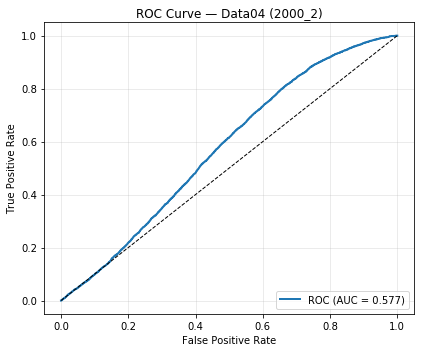

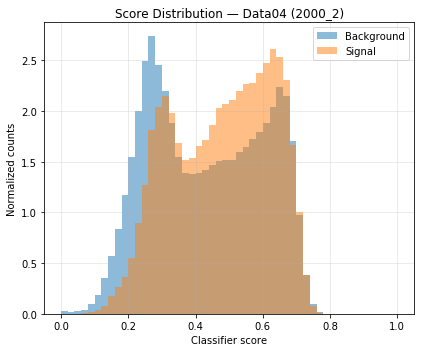


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5870, MaxSIC = 1.0391
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5867, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5913, MaxSIC = 1.0398
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5894, MaxSIC = 1.0387
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5888, MaxSIC = 1.0430
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5842, MaxSIC = 1.0388
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5854, MaxSIC = 

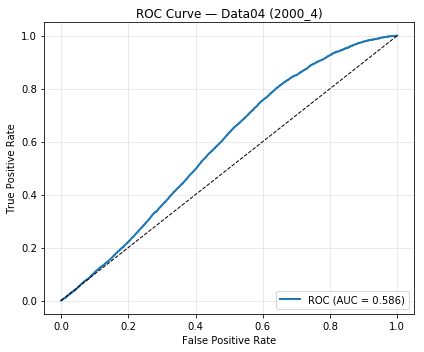

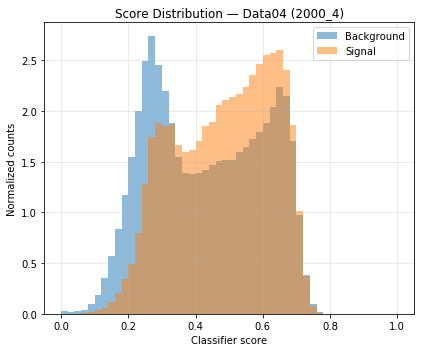


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5858, MaxSIC = 1.0333
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5846, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5904, MaxSIC = 1.0386
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5880, MaxSIC = 1.0363
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5879, MaxSIC = 1.0391
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5826, MaxSIC = 1.0352
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5833, MaxSIC = 

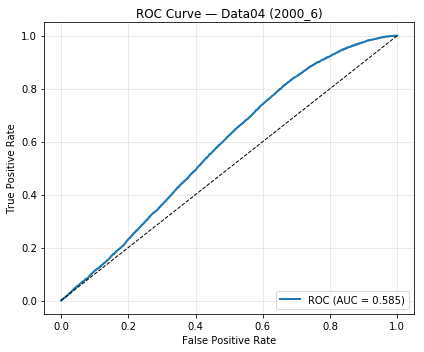

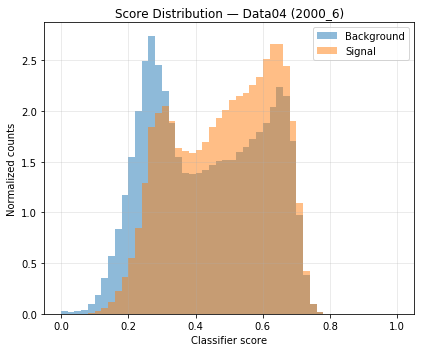


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5774, MaxSIC = 1.0297
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5770, MaxSIC = 1.0346
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5817, MaxSIC = 1.0333
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5795, MaxSIC = 1.0304
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5789, MaxSIC = 1.0338
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5738, MaxSIC = 1.0316
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5749, MaxSIC = 

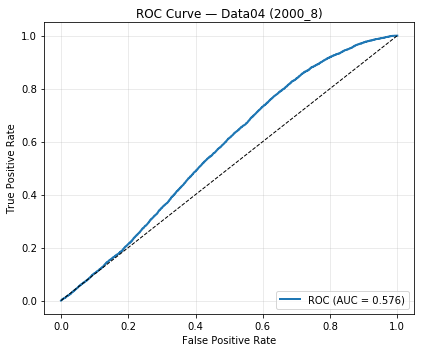

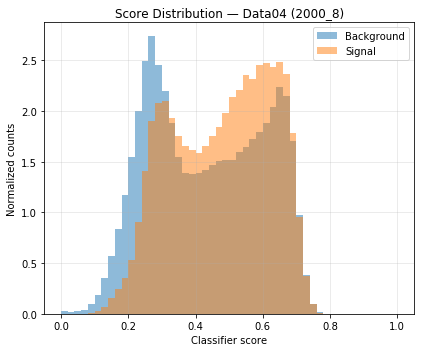


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4227, MaxSIC = 1.0017
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4186, MaxSIC = 1.0026
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4229, MaxSIC = 1.0031
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4244, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4220, MaxSIC = 1.0012
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4191, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.4222, MaxSIC = 

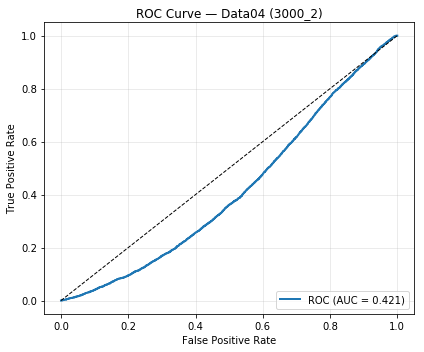

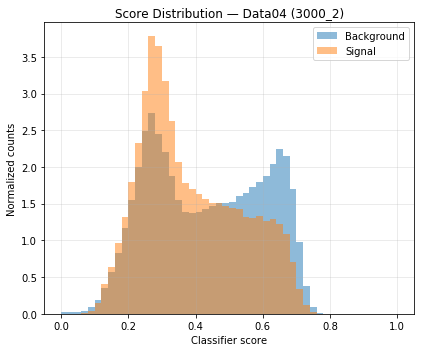


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4445, MaxSIC = 1.0012
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4416, MaxSIC = 1.0015
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4450, MaxSIC = 1.0021
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4463, MaxSIC = 1.0013
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4449, MaxSIC = 1.0010
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4405, MaxSIC = 1.0008
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.4439, MaxSIC = 

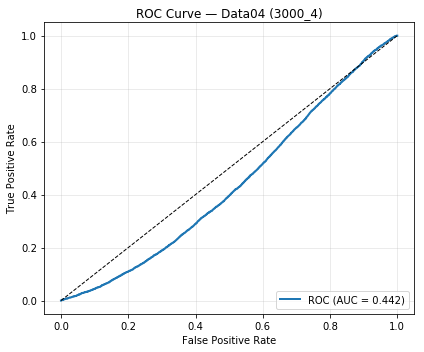

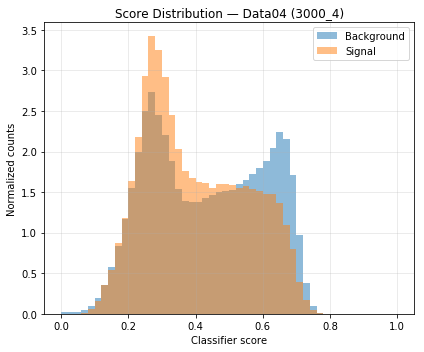


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4625, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4597, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4641, MaxSIC = 1.0027
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4654, MaxSIC = 1.0012
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4631, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4592, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.4623, MaxSIC = 

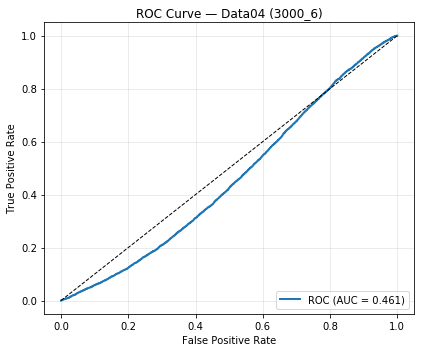

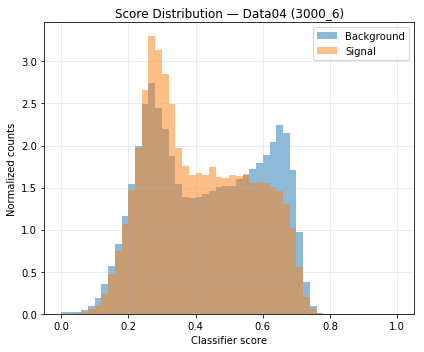


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4697, MaxSIC = 1.0016
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4656, MaxSIC = 1.0018
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4694, MaxSIC = 1.0026
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4702, MaxSIC = 1.0015
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4687, MaxSIC = 1.0015
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4645, MaxSIC = 1.0007
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.4677, MaxSIC = 

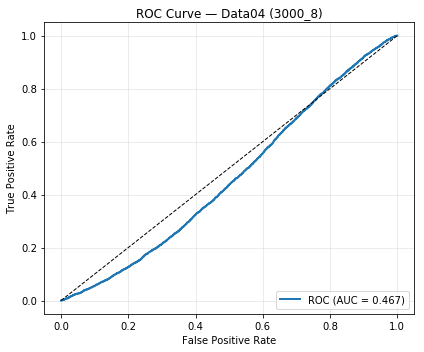

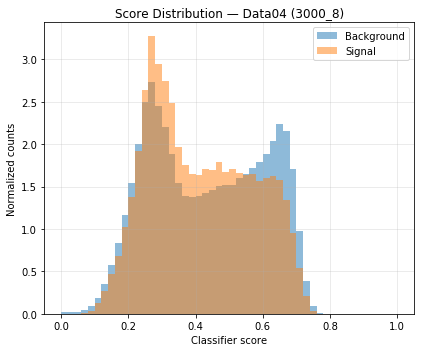


=== Evaluating models for Data05 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6603, MaxSIC = 1.0881
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6625, MaxSIC = 1.0804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6718, MaxSIC = 1.0935
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6645, MaxSIC = 1.0920
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6692, MaxSIC = 1.0893
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6541, MaxSIC = 1.0878
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_

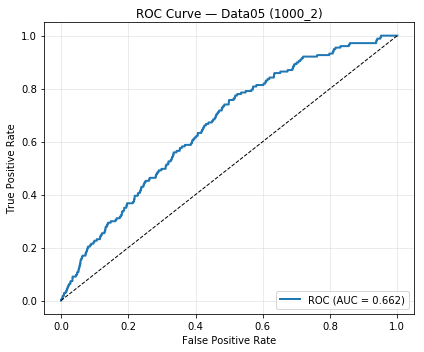

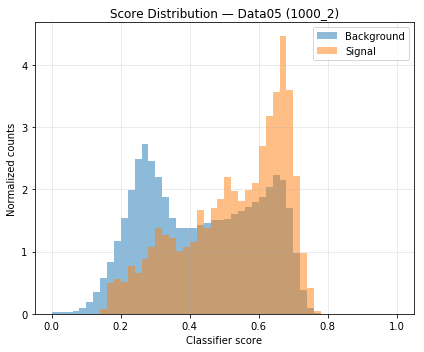


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6840, MaxSIC = 1.1234
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6859, MaxSIC = 1.1341
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6913, MaxSIC = 1.1418
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6861, MaxSIC = 1.1345
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6906, MaxSIC = 1.1381
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6796, MaxSIC = 1.1399
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6793, MaxSIC = 

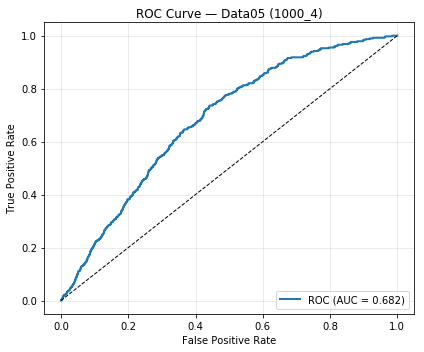

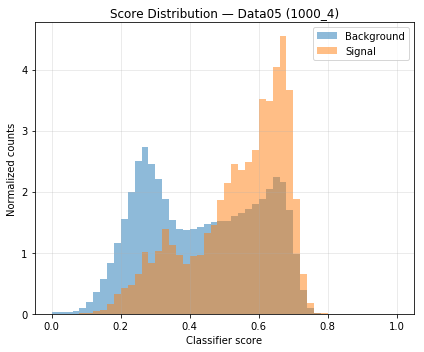


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6872, MaxSIC = 1.1290
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6880, MaxSIC = 1.1372
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6960, MaxSIC = 1.1579
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6893, MaxSIC = 1.1224
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6925, MaxSIC = 1.1401
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6844, MaxSIC = 1.1308
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6834, MaxSIC = 

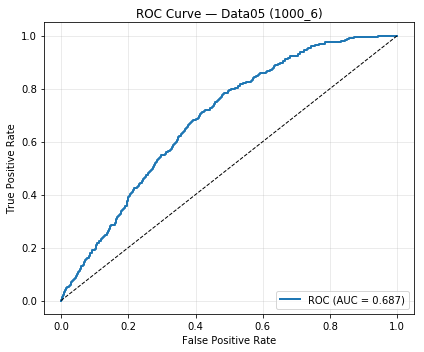

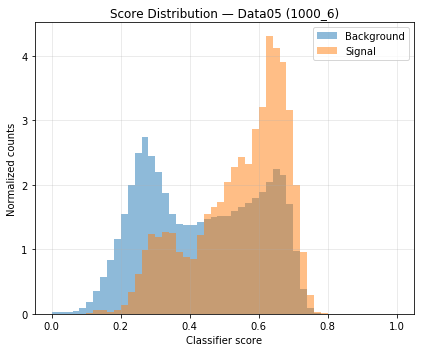


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6690, MaxSIC = 1.1348
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6651, MaxSIC = 1.1308
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6748, MaxSIC = 1.1355
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6669, MaxSIC = 1.1333
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6704, MaxSIC = 1.1320
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6593, MaxSIC = 1.1346
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6589, MaxSIC = 

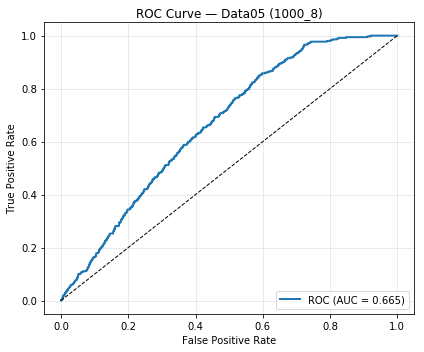

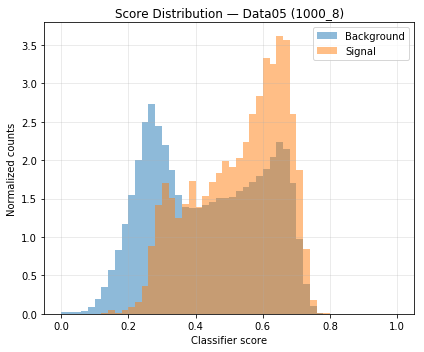


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5784, MaxSIC = 1.0327
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5773, MaxSIC = 1.0340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5820, MaxSIC = 1.0314
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5802, MaxSIC = 1.0313
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5798, MaxSIC = 1.0368
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5750, MaxSIC = 1.0311
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5764, MaxSIC = 

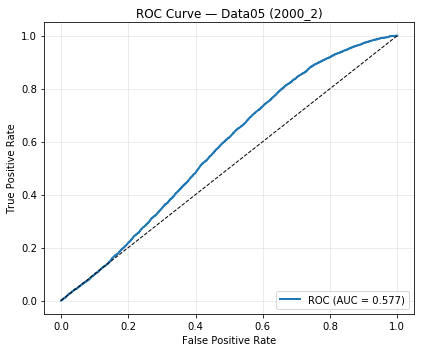

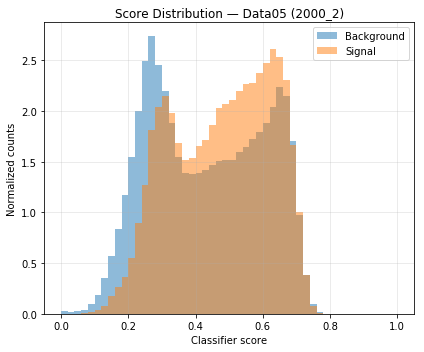


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5870, MaxSIC = 1.0391
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5867, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5913, MaxSIC = 1.0398
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5894, MaxSIC = 1.0387
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5888, MaxSIC = 1.0430
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5842, MaxSIC = 1.0388
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5854, MaxSIC = 

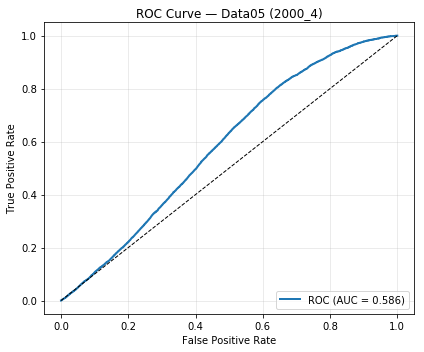

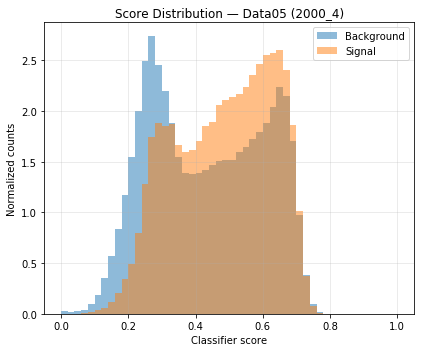


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5858, MaxSIC = 1.0333
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5846, MaxSIC = 1.0401
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5904, MaxSIC = 1.0386
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5880, MaxSIC = 1.0363
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5879, MaxSIC = 1.0391
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5826, MaxSIC = 1.0352
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5833, MaxSIC = 

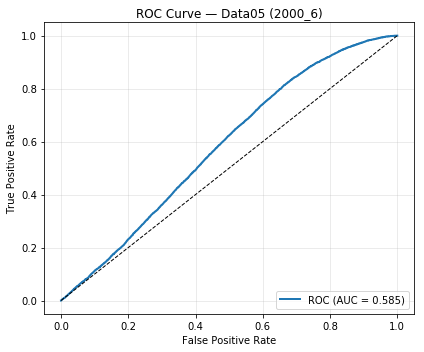

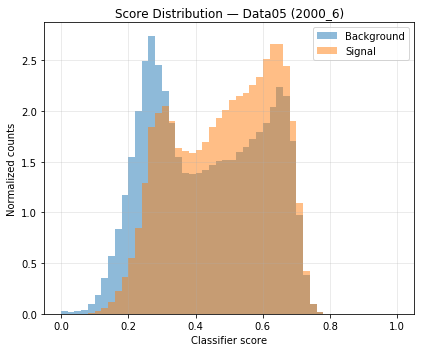


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5774, MaxSIC = 1.0297
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5770, MaxSIC = 1.0346
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5817, MaxSIC = 1.0333
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5795, MaxSIC = 1.0304
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5789, MaxSIC = 1.0338
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5738, MaxSIC = 1.0316
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5749, MaxSIC = 

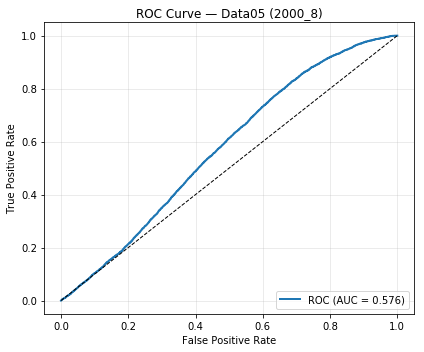

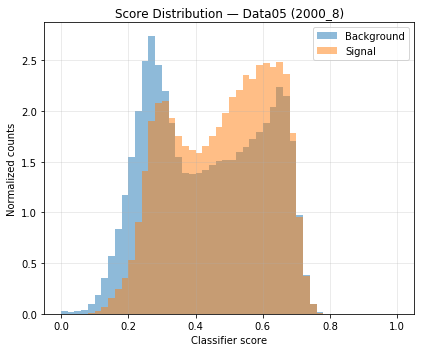


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4227, MaxSIC = 1.0017
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4186, MaxSIC = 1.0026
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4229, MaxSIC = 1.0031
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4244, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4220, MaxSIC = 1.0012
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4191, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.4222, MaxSIC = 

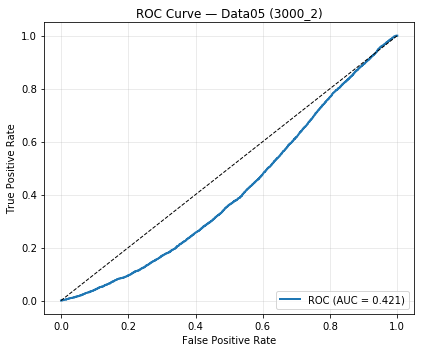

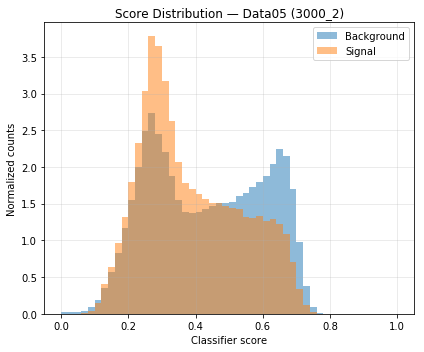


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4445, MaxSIC = 1.0012
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4416, MaxSIC = 1.0015
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4450, MaxSIC = 1.0021
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4463, MaxSIC = 1.0013
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4449, MaxSIC = 1.0010
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4405, MaxSIC = 1.0008
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.4439, MaxSIC = 

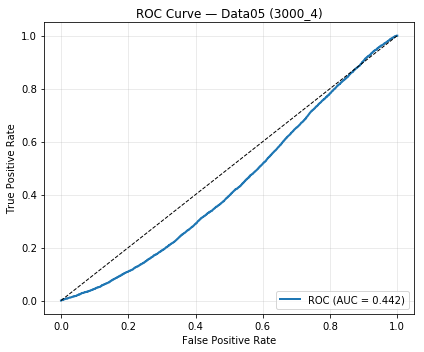

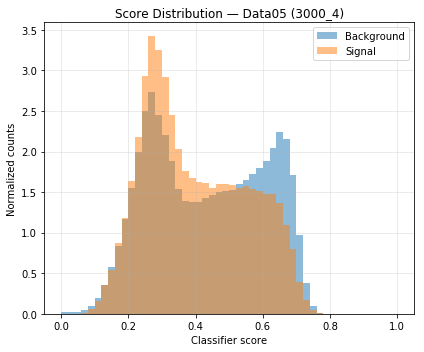


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4625, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4597, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4641, MaxSIC = 1.0027
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4654, MaxSIC = 1.0012
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4631, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4592, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.4623, MaxSIC = 

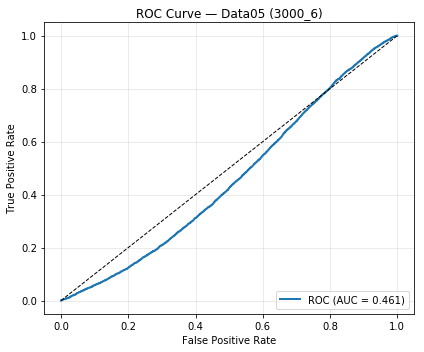

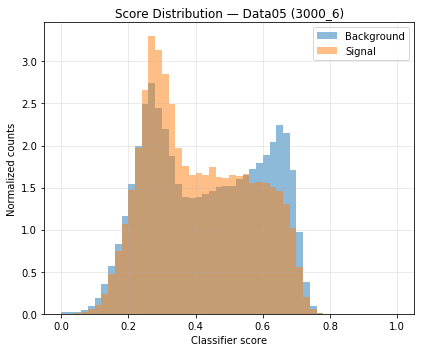


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4697, MaxSIC = 1.0016
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4656, MaxSIC = 1.0018
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4694, MaxSIC = 1.0026
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4702, MaxSIC = 1.0015
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4687, MaxSIC = 1.0015
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4645, MaxSIC = 1.0007
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.4677, MaxSIC = 

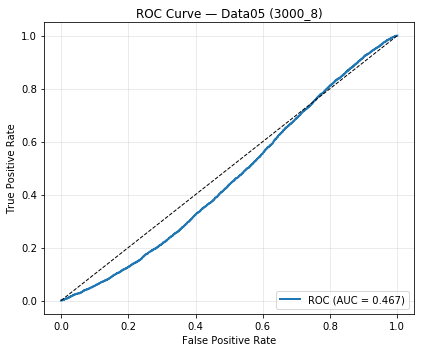

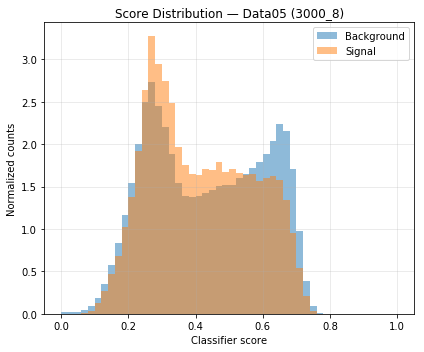


=== ✅ Evaluation complete ===


In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# -----------------------------
# Evaluation Loop
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = {}

n_context = 2
n_runs = 20

results = {}          # stores AUCs
maxsic_results = {}   # stores maxSIC values

n_context = 2  # skip first 2 columns → use last 5 features

for dataset, model_paths in reweight_models_paths.items():
    print(f"\n=== Evaluating models for {dataset} ===")

    results[dataset] = {}
    maxsic_results[dataset] = {}

    for mode in signal_modes:
        print(f"\n--- Signal mode: {mode} ---")

        model_aucs = []
        model_maxsics = []
        all_scores_sig = []
        all_scores_bkg = []
        # Loop over all 20 runs for this dataset
        for run in range(n_runs):
            if run >= len(model_paths):
                print(f"   ⚠️ Skipping run {run}, not enough models found.")
                continue

            model_path = model_paths[run]
            print(f"   ▶️ Run {run+1:02d}: {model_path}")

            # Load trained model
            NN = torch.load(model_path, map_location=device, weights_only=False)
            NN.to(device)
            NN.model.eval()

            # Prepare data
            input_x_test = x_test[mode][:, n_context:]  # numpy array (N, 5)
            input_y_test = y_test[mode]                 # numpy array (N,)

            # Evaluate model
            scores = NN.evaluation(input_x_test)
            scores = np.squeeze(scores)
            

            all_scores_sig.extend(scores[input_y_test == 1])
            all_scores_bkg.extend(scores[input_y_test == 0])
            # Compute AUC
            auc = roc_auc_score(input_y_test, scores)
            # if auc < 0.5:
            #     auc = 1.0 - auc

            # Compute SIC metrics
            fpr, tpr, _ = roc_curve(input_y_test, scores)
            fpr_nonzero = fpr[fpr != 0]
            tpr_nonzero = tpr[fpr != 0]

            rejection = 1.0 / fpr_nonzero
            sic = tpr_nonzero / np.sqrt(fpr_nonzero)

            # Calculate maxSIC above cutoff
            eps_bkg = 1.0 / ((0.4**2) * n_bkg)
            fpr_cutoff = fpr_nonzero > eps_bkg
            if np.any(fpr_cutoff):
                maxsic = np.nanmax(sic[fpr_cutoff])
            else:
                maxsic = np.nan

            print(f"      AUC = {auc:.4f}, MaxSIC = {maxsic:.4f}")

            model_aucs.append(auc)
            model_maxsics.append(maxsic)

        # Store per-mode results
        results[dataset][mode] = model_aucs
        maxsic_results[dataset][mode] = model_maxsics

        # -----------------------------
        # 📈 Plot ROC Curve (AUC)
        # -----------------------------
        plt.figure(figsize=(6, 5))
        mean_auc = np.mean(model_aucs)
        plt.plot(fpr, tpr, label=f"ROC (AUC = {mean_auc:.3f})", lw=2)
        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {dataset} ({mode})")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/roc_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

        # -----------------------------
        # 📊 Plot Score Distributions
        # -----------------------------
        plt.figure(figsize=(6, 5))
        plt.hist(all_scores_bkg, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:blue', label='Background', density=True)
        plt.hist(all_scores_sig, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:orange', label='Signal', density=True)
        plt.xlabel("Classifier score")
        plt.ylabel("Normalized counts")
        plt.title(f"Score Distribution — {dataset} ({mode})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/scores_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

print("\n=== ✅ Evaluation complete ===")

In [17]:
# -----------------------------
# Summary statistics
# -----------------------------

    # print(f"\n--- Dataset: {dataset} ---")
for mode in signal_modes:
    auc_sig = []
    maxsic_sig = []
    for dataset in results.keys():
        aucs = np.array(results[dataset][mode])
        maxsics = np.array(maxsic_results[dataset][mode])

        mean_auc = np.nanmean(aucs)
        mean_maxsic = np.nanmean(maxsics)
        auc_sig.append(mean_auc)
        maxsic_sig.append(mean_maxsic)

    print(f"Mode {mode}:")
    print(f"   Mean AUC   = {np.mean(auc_sig):.4f}")
    print(f"   Mean MaxSIC = {np.mean(maxsic_sig):.4f}")

Mode 1000_2:
   Mean AUC   = 0.6621
   Mean MaxSIC = 1.0871
Mode 1000_4:
   Mean AUC   = 0.6823
   Mean MaxSIC = 1.1271
Mode 1000_6:
   Mean AUC   = 0.6871
   Mean MaxSIC = 1.1319
Mode 1000_8:
   Mean AUC   = 0.6650
   Mean MaxSIC = 1.1294
Mode 2000_2:
   Mean AUC   = 0.5770
   Mean MaxSIC = 1.0313
Mode 2000_4:
   Mean AUC   = 0.5860
   Mean MaxSIC = 1.0383
Mode 2000_6:
   Mean AUC   = 0.5845
   Mean MaxSIC = 1.0358
Mode 2000_8:
   Mean AUC   = 0.5762
   Mean MaxSIC = 1.0312
Mode 3000_2:
   Mean AUC   = 0.4205
   Mean MaxSIC = 1.0018
Mode 3000_4:
   Mean AUC   = 0.4425
   Mean MaxSIC = 1.0014
Mode 3000_6:
   Mean AUC   = 0.4614
   Mean MaxSIC = 1.0014
Mode 3000_8:
   Mean AUC   = 0.4670
   Mean MaxSIC = 1.0017
